# 💳 Credit Card Fraud Detection

## End-to-End Machine Learning Capstone Project

This project aims to detect fraudulent credit card transactions using machine learning.

### Project Workflow
- Data Loading
- Data Cleaning
- Exploratory Data Analysis
- Handling Class Imbalance
- Feature Engineering
- Model Training
- Model Evaluation
- Best Model Selection
- Model Deployment using Streamlit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load the Dataset

The Credit Card Fraud Detection dataset contains transactions made by credit cards.  
We will first load the dataset and inspect its structure, size, and available features.

In [2]:
# Load the dataset
df = pd.read_csv("../data/creditcard.csv")

# Display dataset shape
print("Dataset Shape:", df.shape)

# Display first 5 rows
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Initial Data Inspection

Before preprocessing, we will inspect the dataset structure, data types, and missing values to understand the quality of the data.

In [3]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

### Checking Missing Values

We will check whether any columns contain missing values.

In [4]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total Missing Values: 0


## 3. Class Distribution

The target variable is `Class`:

- `0` = Normal Transaction
- `1` = Fraudulent Transaction

We will analyze the class distribution to determine whether the dataset is imbalanced.

In [5]:
# Count each class
class_counts = df["Class"].value_counts()

print("Class Distribution:")
print(class_counts)

# Calculate percentages
class_percentages = df["Class"].value_counts(normalize=True) * 100

print("\nClass Distribution (%):")
print(class_percentages)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Distribution (%):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


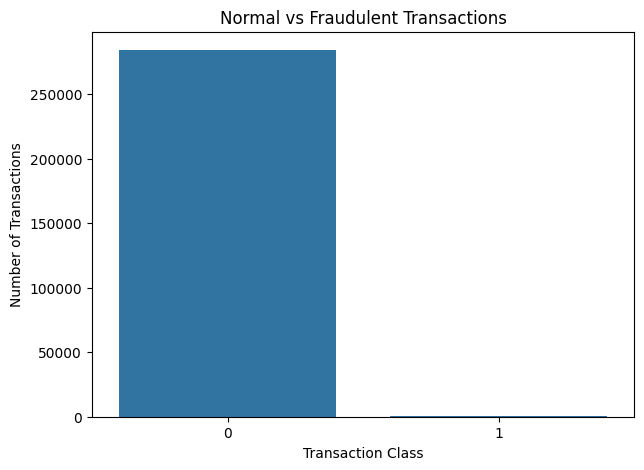

In [6]:
# Visualize class distribution

plt.figure(figsize=(7, 5))

sns.countplot(x="Class", data=df)

plt.title("Normal vs Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()


## 4. Exploratory Data Analysis

We will explore the transaction amount and compare it between normal and fraudulent transactions to identify useful patterns.

In [7]:
# Summary statistics for transaction amount
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

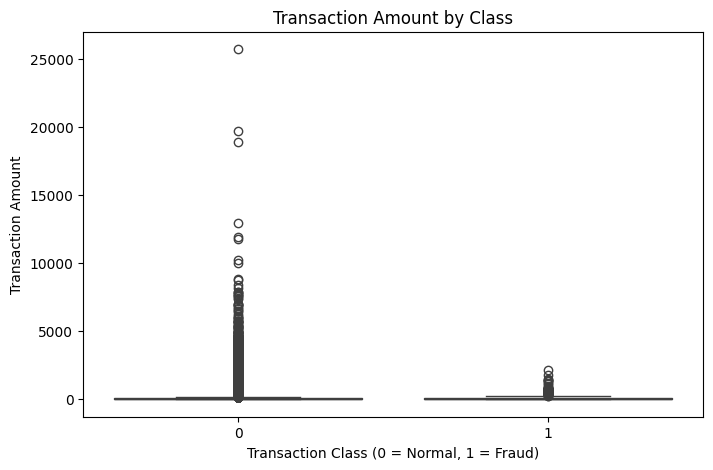

In [8]:
# Compare transaction amount for normal and fraudulent transactions

plt.figure(figsize=(8, 5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

## 5. Transaction Time Analysis

The `Time` feature represents the elapsed time between transactions.

We will visualize the distribution of transaction times for normal and fraudulent transactions.

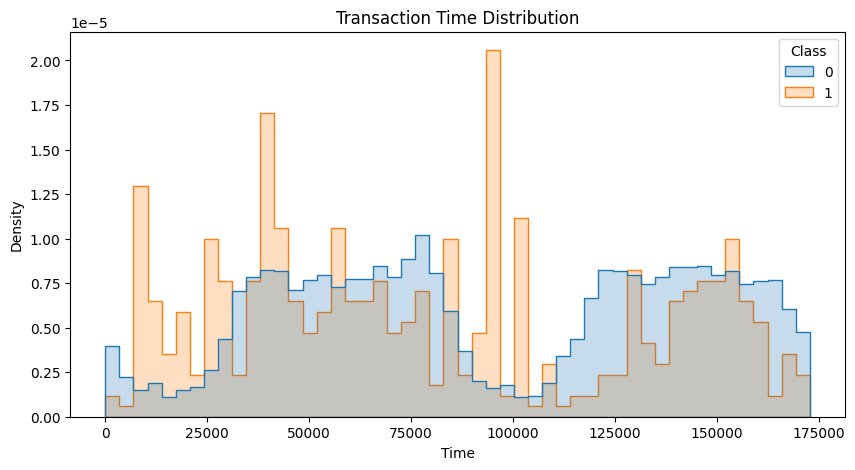

In [9]:
# Plot transaction time distribution by class

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Density")

plt.show()

## 6. Correlation Analysis

Correlation helps us understand the relationship between numerical features and the target variable.

We will visualize the correlations to identify features that may be useful for fraud detection.

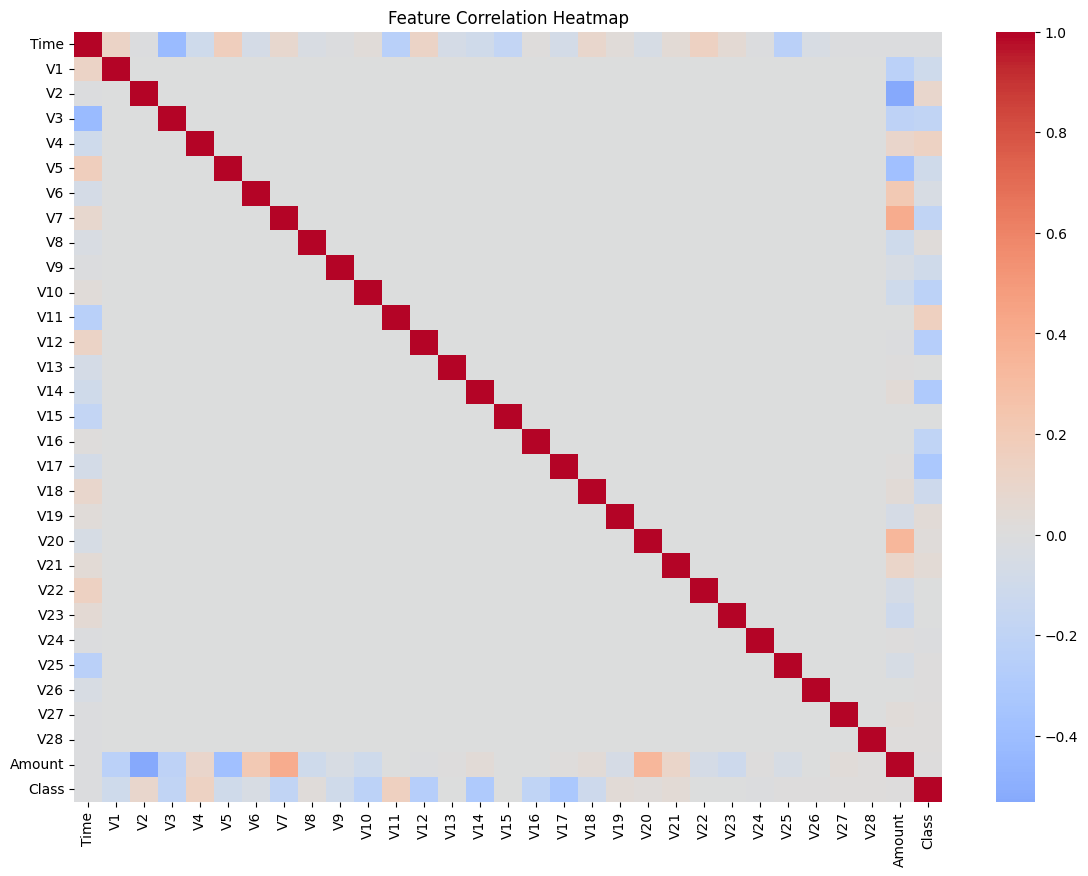

In [10]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

## 7. Data Preprocessing

Before training the machine learning models, we will prepare the features and target variable.

- `Class` will be used as the target variable.
- `Time` and `Amount` will be standardized.
- The remaining PCA-transformed features will be kept unchanged.

In [11]:
from sklearn.preprocessing import StandardScaler

# Create a copy of the dataset
df_processed = df.copy()

# Initialize scaler
scaler = StandardScaler()

# Standardize Time and Amount
df_processed["Time"] = scaler.fit_transform(
    df_processed[["Time"]]
)

df_processed["Amount"] = scaler.fit_transform(
    df_processed[["Amount"]]
)

# Display the first 5 rows
df_processed.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


## 8. Feature-Target Separation

The `Class` column is our target variable.

- `X` contains the transaction features.
- `y` contains the target labels: normal (`0`) or fraudulent (`1`).

In [12]:
# Separate features and target
X = df_processed.drop("Class", axis=1)
y = df_processed["Class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (284807, 30)
Target Shape: (284807,)


## 9. Train-Test Split

We will split the dataset into training and testing sets.

Stratification is used to preserve the original ratio of normal and fraudulent transactions in both sets.

In [13]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 227845
Testing samples: 56962

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


## 10. Baseline Model — Logistic Regression

We will first train a Logistic Regression model without applying any class-balancing technique.

This baseline will help us understand how the model performs on the original imbalanced dataset.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train baseline Logistic Regression model
baseline_model = LogisticRegression(max_iter=1000, random_state=42)

baseline_model.fit(X_train, y_train)

# Make predictions
y_pred_baseline = baseline_model.predict(X_test)

# Evaluate baseline model
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print("Baseline Logistic Regression Results")
print("------------------------------------")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-Score : {baseline_f1:.4f}")

Baseline Logistic Regression Results
------------------------------------
Accuracy : 0.9992
Precision: 0.8289
Recall   : 0.6429
F1-Score : 0.7241


## 11. Handling Class Imbalance — Class Weighting

The dataset is highly imbalanced, with fraudulent transactions representing only 0.17% of all transactions.

To give more importance to the minority fraud class, we will train Logistic Regression using `class_weight="balanced"`.

This will allow the model to penalize incorrect predictions of fraudulent transactions more strongly.

In [15]:
# Train Logistic Regression with class weighting
weighted_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

weighted_model.fit(X_train, y_train)

# Predictions
y_pred_weighted = weighted_model.predict(X_test)

# Evaluation
weighted_accuracy = accuracy_score(y_test, y_pred_weighted)
weighted_precision = precision_score(y_test, y_pred_weighted)
weighted_recall = recall_score(y_test, y_pred_weighted)
weighted_f1 = f1_score(y_test, y_pred_weighted)

print("Class-Weighted Logistic Regression Results")
print("------------------------------------------")
print(f"Accuracy : {weighted_accuracy:.4f}")
print(f"Precision: {weighted_precision:.4f}")
print(f"Recall   : {weighted_recall:.4f}")
print(f"F1-Score : {weighted_f1:.4f}")

Class-Weighted Logistic Regression Results
------------------------------------------
Accuracy : 0.9755
Precision: 0.0609
Recall   : 0.9184
F1-Score : 0.1141


## 12. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to make predictions.

We will train a Random Forest model with class weighting to improve its ability to detect the minority fraud class.

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest with class weighting
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")

Random Forest Results
---------------------
Accuracy : 0.9995
Precision: 0.9605
Recall   : 0.7449
F1-Score : 0.8391


## 13. XGBoost Classifier

XGBoost is a powerful gradient boosting algorithm that builds an ensemble of decision trees sequentially.

We will train an XGBoost classifier and compare its performance with Logistic Regression and Random Forest.

In [17]:
# Check whether XGBoost is installed

try:
    import xgboost as xgb
    print("XGBoost is installed successfully!")
except ImportError:
    print("XGBoost is not installed.")

XGBoost is installed successfully!


## 13.1 Train XGBoost Model

We will train an XGBoost classifier and evaluate it using accuracy, precision, recall, and F1-score.

These metrics will help us compare XGBoost fairly with the other models.

In [19]:
import xgboost as xgb

# Calculate scale_pos_weight for the minority fraud class
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale Pos Weight:", scale_pos_weight)

# Create XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("\nXGBoost Results")
print("---------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")

Scale Pos Weight: 577.2868020304569

XGBoost Results
---------------
Accuracy : 0.9983
Precision: 0.5000
Recall   : 0.8469
F1-Score : 0.6288


## 14. Confusion Matrix — Random Forest

The confusion matrix shows how the Random Forest model classified normal and fraudulent transactions.

It helps us identify:
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

Confusion Matrix:
[[56861     3]
 [   25    73]]


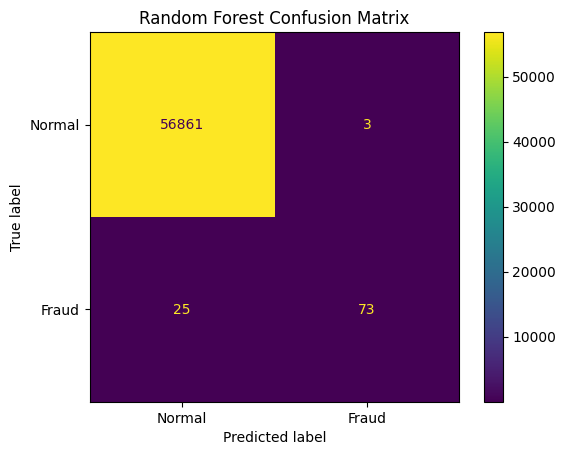

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

## 15. ROC-AUC Evaluation

ROC-AUC measures how well the model can distinguish between normal and fraudulent transactions across different classification thresholds.

A higher AUC indicates better discrimination between the two classes.

Random Forest ROC-AUC: 0.9529


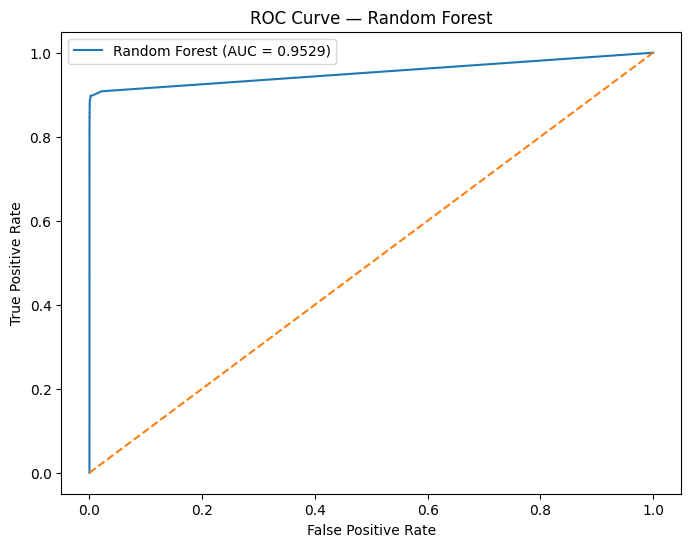

In [21]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get probability scores for the fraud class
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forest ROC-AUC: {rf_auc:.4f}")

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {rf_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()

plt.show()

## 16. Model Performance Comparison

We trained multiple machine learning models and evaluated them using Accuracy, Precision, Recall, and F1-Score.

Because this is an imbalanced fraud detection problem, F1-Score, Precision, and Recall are more informative than accuracy alone.

In [22]:
# Create model comparison table

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Weighted Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        baseline_accuracy,
        weighted_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        baseline_precision,
        weighted_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        baseline_recall,
        weighted_recall,
        rf_recall,
        xgb_recall
    ],
    "F1-Score": [
        baseline_f1,
        weighted_f1,
        rf_f1,
        xgb_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.999157,0.828947,0.642857,0.724138
1,Weighted Logistic Regression,0.975475,0.060852,0.918367,0.114141
2,Random Forest,0.999508,0.960526,0.744898,0.839080
3,XGBoost,0.998280,0.500000,0.846939,0.628788


## Model Performance Comparison

The performance of all models is compared using Accuracy, Precision, Recall, and F1-Score. Since the dataset is highly imbalanced, Precision, Recall, and F1-Score are more informative than Accuracy alone.

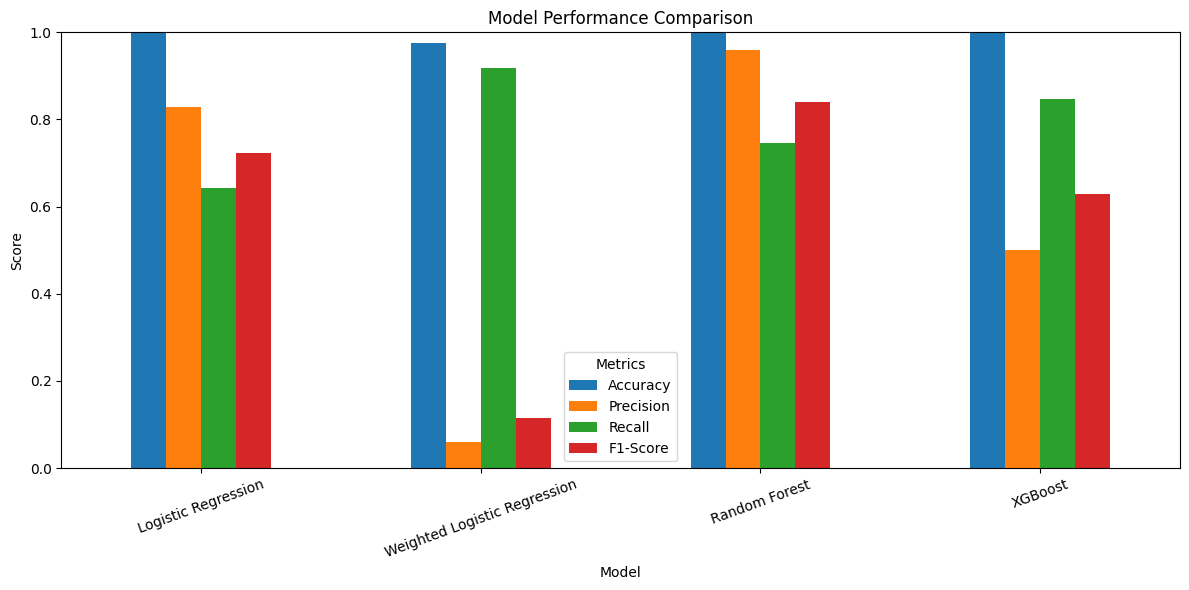

In [23]:
# Plot model performance comparison

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

## Best Model Selection

Based on the comparison of Accuracy, Precision, Recall, and F1-Score, the models are evaluated with special attention to Recall and F1-Score because the dataset is highly imbalanced. The model with the most suitable balance between Precision and Recall will be selected as the final model.

In [24]:
# Find the best model based on F1-Score

best_model = results.loc[results["F1-Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model        Random Forest
Accuracy          0.999508
Precision         0.960526
Recall            0.744898
F1-Score           0.83908
Name: 2, dtype: object


## Confusion Matrix of the Best Model

The confusion matrix is used to evaluate the classification performance of the selected Random Forest model. It shows the number of correctly and incorrectly classified samples for each class.

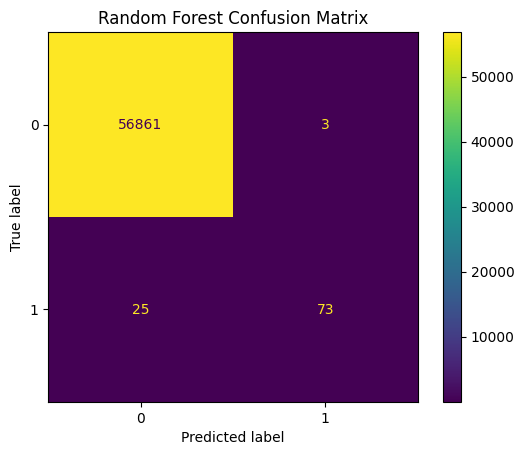

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions using Random Forest
rf_pred = rf_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, rf_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

## Save Final Model

The Random Forest model was selected as the final model based on its overall performance, particularly its F1-Score, Precision, and Recall. The trained model will be saved for deployment in the Streamlit application.

In [26]:
import joblib

# Save the final Random Forest model
joblib.dump(rf_model, "fraud_detection_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [27]:
import os

print("Model file exists:", os.path.exists("fraud_detection_model.pkl"))

Model file exists: True


In [28]:
print("Model features:")
print(rf_model.feature_names_in_)

print("\nNumber of features:")
print(len(rf_model.feature_names_in_))

Model features:
['Time' 'V1' 'V2' 'V3' 'V4' 'V5' 'V6' 'V7' 'V8' 'V9' 'V10' 'V11' 'V12'
 'V13' 'V14' 'V15' 'V16' 'V17' 'V18' 'V19' 'V20' 'V21' 'V22' 'V23' 'V24'
 'V25' 'V26' 'V27' 'V28' 'Amount']

Number of features:
30
